# Exploratory Data Analysis (EDA) - Booking Cancellation Patterns

In this notebook, I transitioned from SQL-based aggregation to deeper visual and statistical exploration using Python.

My goal was to uncover nuanced relationships and patterns in the booking behaviour, particularly those that might influence the likelyhood of cancellations.

I used techniques like correlation heatmaps, trend plots, and comparative visualizations to investigate variable interactions, outliers, and trends.

In [2]:
# Core Librabries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Notebook Styling
sns.set_theme(style = 'whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Suppress Warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load the cleared dataset
df = pd.read_csv('../data/processed/hotel_bookings_cleaned.csv')
df.shape

(87396, 33)

## Variable Relationships and Correlations

As a first step, I wanted to assess how numerical variables are related. This would help me prioritize features that might correlate with cancellations

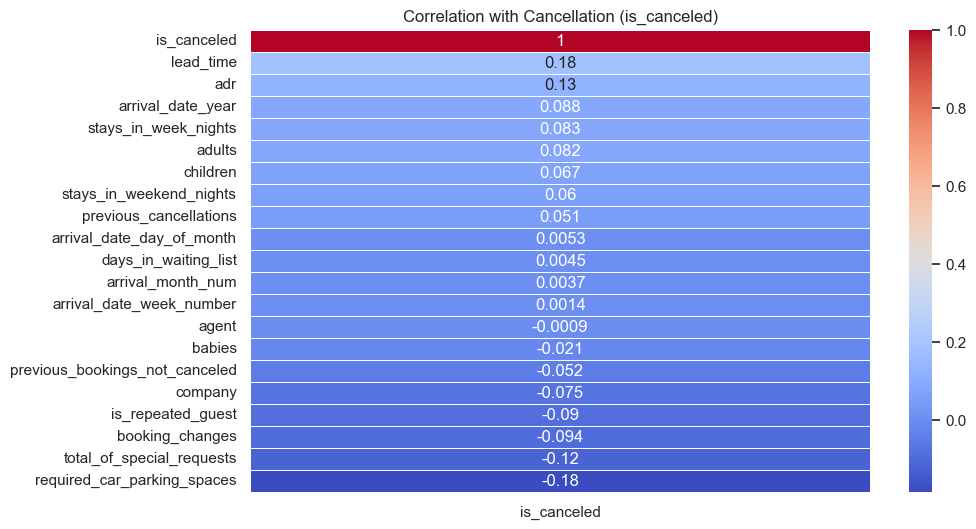

In [4]:
# Extract only numeric features
numeric_df = df.select_dtypes(include = ['int64', 'float64'])

# Create a correlation matrixx
corr = numeric_df.corr()

# Focused Heatmap (top correlations with cancellation)

sns.heatmap(corr[['is_canceled']].sort_values(by='is_canceled', ascending=False),
            annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation with Cancellation (is_canceled)")
plt.show()

### Correlation Analysis Summary

To identify variables most associated with cancellations, I computed a correlation matrix of all numeric features.

**Key observations from the heatmap:**
- `lead_time` has the strongest **positive correlation** with cancellations (`+0.18`), suggesting that bookings made well in advance are more likely to be canceled.
- `adr` (average daily rate) also shows a mild positive correlation (`+0.13`),  possibly indicating price-sensitive behavior.
- On the flip side, **negative correlations** were found in:
  - `required_car_parking_spaces` (`-0.18`)
  - `total_of_special_requests` (`-0.12`)
  - `is_repeated_guest` (`-0.09`)

These patterns suggest that repeat guests and those with more specific needs (e.g., parking, special requests) are less likely to cancel, possibly due to higher commitment levels.

---


## Lead Time vs Cancellation

Based on the earlier correlation analysis, `lead_time` had the strongest positive correlation with cancellations. 

To explore this further, I plotted the distribution of lead times separately for canceled and non-canceled bookings. This helps visualize whether bookings made far in advance are more prone to cancellation.


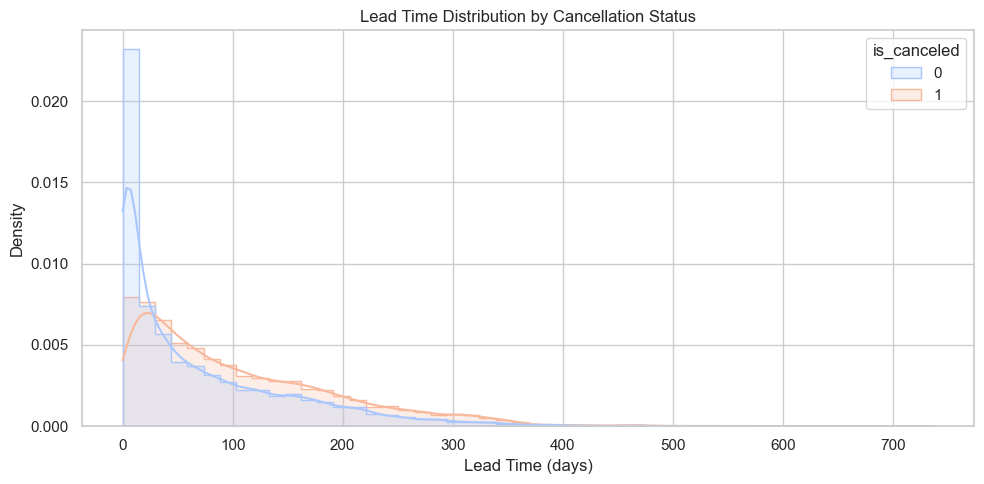

<span style='color: grey; font-size: 0.9em'><i>Density plot comparing lead time distributions between canceled and non-canceled bookings. Longer lead times (above 60 days) show a noticeably higher proportion of cancellations.</i></span>

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="lead_time", hue="is_canceled", bins=50, kde=True, palette="coolwarm", element="step", stat="density", common_norm=False)
plt.title("Lead Time Distribution by Cancellation Status")
plt.xlabel("Lead Time (days)")
plt.ylabel("Density")
# plt.legend(title="Is Canceled", labels=["No", "Yes"])
plt.tight_layout()
plt.show()


from IPython.display import display, Markdown
display(Markdown("<span style='color: grey; font-size: 0.9em'><i>Density plot comparing lead time distributions between canceled and non-canceled bookings. Longer lead times (above 60 days) show a noticeably higher proportion of cancellations.</i></span>"))


### Insight: Lead Time vs Cancellation

From the lead time distribution analysis, I found that **bookings with longer lead times** (booked far in advance) were **more likely to be canceled** compared to bookings made closer to the arrival date.  
Guests booking at the last minute (short lead time) showed significantly **lower cancellation rates**.

This suggests that **higher lead times introduce more uncertainty**, making cancellations more common.



<div style='background-color: #f9f9f9; padding: 10px; border-left: 4px solid #ccc; font-size: 90%;'>
<b>💡 Key Takeaway:</b><br>
Bookings made further in advance are more likely to be canceled. Shorter lead times are associated with higher commitment.
</div>

---

## ADR (Average Daily Rate) vs Cancellation

After exploring lead time, I wanted to investigate if the price paid per night (ADR) had any relationship with cancellation behavior.

I hypothesized that **bookings with extremely high or low ADRs** might have different cancellation tendencies — possibly due to price sensitivity or perceived value.


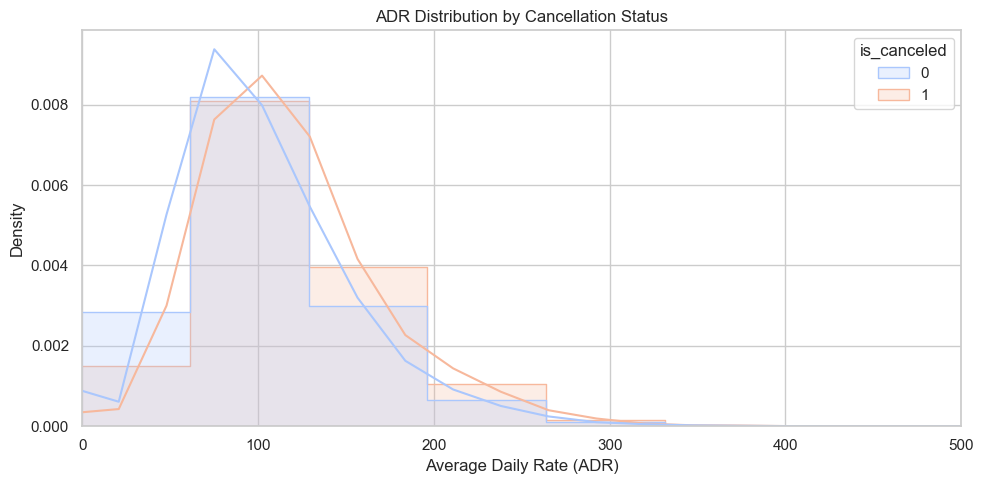

<span style='color: grey; font-size: 0.9em'><i>Density plot comparing ADR distributions between canceled and non-canceled bookings. X-axis limited to ADRs below $500 to remove extreme outliers.</i></span>

In [13]:
# Plot: ADR distribution by cancellation status
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="adr", hue="is_canceled", bins=80, kde=True, palette="coolwarm", element="step", stat="density", common_norm=False)
plt.title("ADR Distribution by Cancellation Status")
plt.xlabel("Average Daily Rate (ADR)")
plt.ylabel("Density")
plt.xlim(0, 500)  # Focus on reasonable ADR values (remove extreme outliers)
plt.tight_layout()
plt.show()

# Light grey caption
from IPython.display import display, Markdown
display(Markdown("<span style='color: grey; font-size: 0.9em'><i>Density plot comparing ADR distributions between canceled and non-canceled bookings. X-axis limited to ADRs below $500 to remove extreme outliers.</i></span>"))


### Insight: ADR vs Cancellation

Analyzing the ADR (Average Daily Rate) distribution revealed interesting patterns:

* Both canceled and non-canceled bookings mostly concentrated around ADR values between **\$50 to \$150**.
* However, canceled bookings showed a **slightly wider spread** towards higher ADRs compared to non-canceled ones.
* I observed **no strong shift** suggesting extreme ADRs alone drive cancellations, but a **mild tendency for cancellations to increase slightly** with higher nightly rates.

This indicates that while ADR influences booking behavior, it likely interacts with other factors (such as lead time, deposit policy, or customer type) to impact cancellations.

<div style='background-color: #f9f9f9; padding: 10px; border-left: 4px solid #ccc; font-size: 90%;'>
<b>💡 Key Takeaway:</b><br>
Higher ADR bookings show a slightly higher tendency toward cancellations, possibly due to greater price sensitivity.
</div>

---

## Special Requests vs Cancellation

Next, I wanted to explore whether guests making special requests were less or more likely to cancel their bookings.

My hypothesis was that guests who made more special requests might have a stronger intent to stay, hence potentially showing a lower cancellation rate. 

To investigate, I grouped bookings by the number of special requests and calculated the corresponding cancellation rates.


In [15]:
# Group by number of special requests and calculate cancellation rate
special_req_cancel_df = df.groupby('total_of_special_requests').agg(
    total_bookings = ('is_canceled', 'count'),
    canceled_bookings = ('is_canceled', 'sum')
).reset_index()

# Calculate the cancellation rate percentage
special_req_cancel_df['cancel_rate_percent'] = round((special_req_cancel_df['canceled_bookings'] / special_req_cancel_df['total_bookings']) * 100, 2)

special_req_cancel_df


,total_of_special_requests,total_bookings,canceled_bookings,cancel_rate_percent
0,0,43894,14574,33.20
1,1,29017,6503,22.41
2,2,11812,2515,21.29
3,3,2317,397,17.13
4,4,320,34,10.62
5,5,36,2,5.56


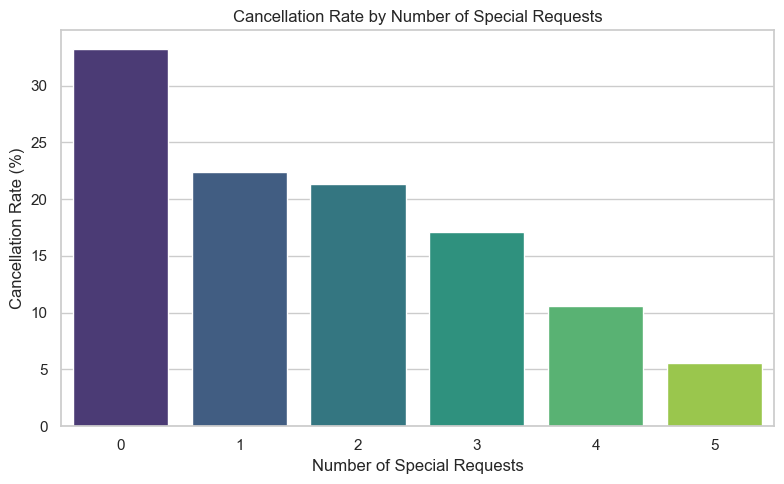

In [16]:
# Plotting Cancellation Rate by Number of Special Requests
plt.figure(figsize=(8,5))
sns.barplot(data=special_req_cancel_df, x='total_of_special_requests', y='cancel_rate_percent', palette='viridis')
plt.title("Cancellation Rate by Number of Special Requests")
plt.xlabel("Number of Special Requests")
plt.ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()


### Insight: Special Requests vs Cancellation

After analyzing the number of special requests made by guests, I observed a clear trend:  
Guests who made **zero special requests** had the **highest cancellation rate (~33%)**, while those who made **more special requests** had progressively **lower cancellation rates**, dropping to about **5%** for guests who made **five** requests.

This suggests that **higher engagement during booking (through customization or specific requests)** might correlate with a **stronger booking commitment**, resulting in fewer cancellations.


<div style='background-color: #f9f9f9; padding: 10px; border-left: 4px solid #ccc; font-size: 90%;'>
<b>💡 Key Takeaway:</b><br>
Higher guest engagement, indicated by making special requests, is associated with a lower likelihood of cancellation.<br>
Encouraging guests to personalize their stays could improve booking retention rates.
</div>

---

### Analyzing ADR by Hotel Type

Next, I wanted to explore whether the average daily rate (ADR) significantly varied between the two hotel types: City Hotel and Resort Hotel.

Understanding the pricing difference could provide insight into customer booking behaviors and revenue strategies across different hotel categories.


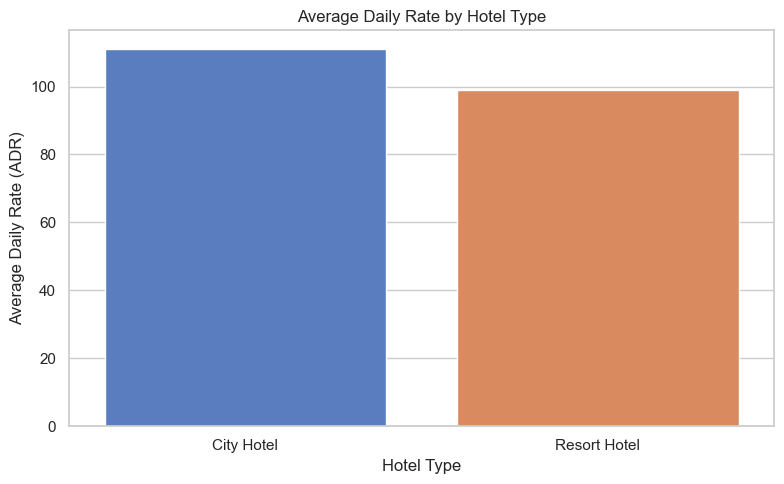

In [20]:
# ADR by Hotel Type
adr_by_hotel = df.groupby('hotel')['adr'].mean().reset_index().sort_values(by='adr', ascending=False)

# Plotting
plt.figure(figsize=(8,5))
sns.barplot(data=adr_by_hotel, x='hotel', y='adr', palette='muted')
plt.title('Average Daily Rate by Hotel Type')
plt.ylabel('Average Daily Rate (ADR)')
plt.xlabel('Hotel Type')
plt.tight_layout()
plt.show()


### Insight: ADR Differences by Hotel Type

From the visualization, I observed that City Hotels had a higher average daily rate (ADR) compared to Resort Hotels.

This suggests that guests at City Hotels typically paid more per night than those staying at Resort Hotels. 
It may reflect different customer segments, operational costs, or location-driven demand characteristics between city centers and resort destinations.

---


## Booking Changes and Cancellation Behavior

Next, I wanted to explore whether customers who made changes to their booking were more or less likely to cancel.  
Intuitively, customers modifying their bookings might reflect uncertainty or changing plans, which could influence cancellation rates.

To investigate this, I grouped the dataset based on the number of booking changes and analyzed their associated cancellation rates.


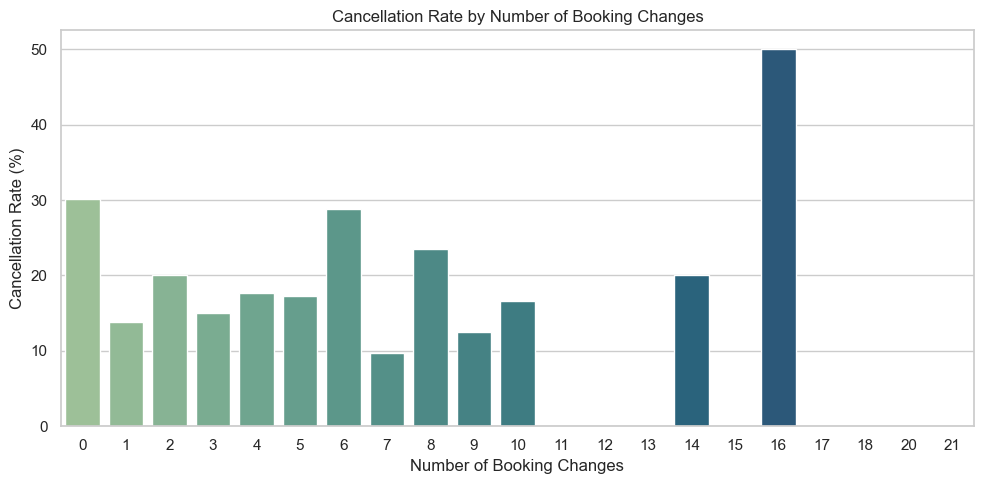

In [21]:
# Group by booking changes
booking_change_cancel_df = df.groupby('booking_changes').agg(
    total_bookings=('is_canceled', 'count'),
    canceled_bookings=('is_canceled', 'sum'),
    cancel_rate_percent=('is_canceled', lambda x: round(x.mean() * 100, 2))
).reset_index()

# Plotting
plt.figure(figsize=(10,5))
sns.barplot(data=booking_change_cancel_df, x='booking_changes', y='cancel_rate_percent', palette='crest')
plt.title("Cancellation Rate by Number of Booking Changes")
plt.xlabel("Number of Booking Changes")
plt.ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()


### Insight: Booking Changes and Cancellation Behavior

The plot showed that bookings with **zero changes** had a higher cancellation rate compared to those with one or more changes.  
Interestingly, customers who made a few adjustments (such as one or two changes) were **less likely** to cancel their booking.

This reinforces the idea that proactive customers—those fine-tuning their reservations—may be more committed, whereas those with no booking activity could represent more casual or uncertain bookings.  
I also noticed a spike at 16 changes, but this is likely an **outlier** due to very few records and will require additional investigation during data validation.


---

## Days in Waiting List vs Cancellation

Next, I wanted to explore whether being on the hotel's waiting list had any relationship with booking cancellations.

Typically, longer wait times could lead to customer frustration or change in plans, potentially increasing cancellation rates.  
To investigate this, I analyzed the distribution of cancellation rates based on the number of days guests spent on the waiting list.


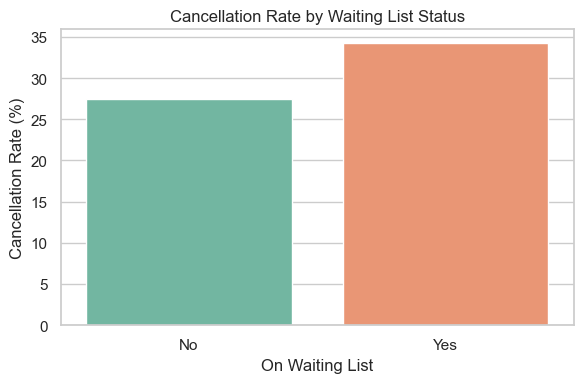

In [22]:
# Analyzing Days in Waiting List vs Cancellation

# Create a binary feature: Was on waiting list or not
df['waiting_list_flag'] = df['days_in_waiting_list'].apply(lambda x: 'Yes' if x > 0 else 'No')

# Calculate cancellation rates for waiting vs non-waiting bookings
waiting_list_cancel_df = df.groupby('waiting_list_flag').agg(
    total_bookings=('is_canceled', 'count'),
    canceled_bookings=('is_canceled', 'sum')
).reset_index()

waiting_list_cancel_df['cancel_rate_percent'] = round((waiting_list_cancel_df['canceled_bookings'] / waiting_list_cancel_df['total_bookings']) * 100, 2)

# Plotting
plt.figure(figsize=(6,4))
sns.barplot(data=waiting_list_cancel_df, x='waiting_list_flag', y='cancel_rate_percent', palette='Set2')
plt.title("Cancellation Rate by Waiting List Status")
plt.xlabel("On Waiting List")
plt.ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()


### Insight: Days in Waiting List vs Cancellation
From the analysis, bookings that involved time on a waiting list exhibited a noticeably higher cancellation rate compared to those that did not.  
This suggests that guests placed on waiting lists may experience reduced commitment or satisfaction, increasing the likelihood of cancellations.

---


## Cancellation Behavior: Repeated Guests vs First-Time Guests

Finally, I wanted to explore whether repeat guests behaved differently from first-time guests when it came to cancellations.

My hypothesis was that repeated guests, due to their familiarity and loyalty to the hotel, would have a lower likelihood of canceling compared to new customers.

To test this, I analyzed the cancellation rates based on the `is_repeated_guest` feature.


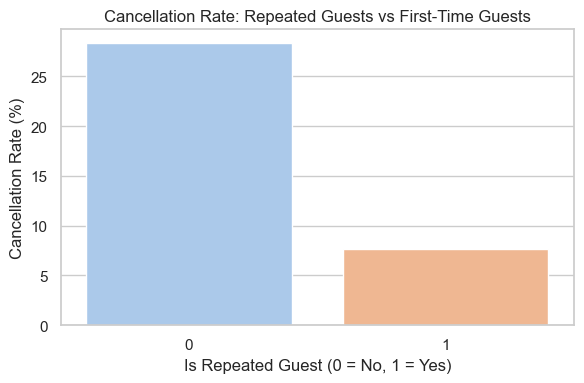

In [23]:
# Analyzing Cancellations by Repeated Guest Status

# Grouping and calculating cancellation rates
repeat_guest_cancel_df = df.groupby('is_repeated_guest').agg(
    total_bookings=('is_canceled', 'count'),
    canceled_bookings=('is_canceled', 'sum')
).reset_index()

repeat_guest_cancel_df['cancel_rate_percent'] = round((repeat_guest_cancel_df['canceled_bookings'] / repeat_guest_cancel_df['total_bookings']) * 100, 2)

# Plotting
plt.figure(figsize=(6,4))
sns.barplot(data=repeat_guest_cancel_df, x='is_repeated_guest', y='cancel_rate_percent', palette='pastel')
plt.title("Cancellation Rate: Repeated Guests vs First-Time Guests")
plt.xlabel("Is Repeated Guest (0 = No, 1 = Yes)")
plt.ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()


### Insight: Repeated Guests vs First-Time Guests
The analysis revealed that repeated guests had a significantly lower cancellation rate compared to first-time guests.  
This suggests that customer loyalty and familiarity with the hotel experience might lead to more reliable bookings and reduced cancellations.

---
